In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Names: Petter, Jone Bakken

Abstract:

Introduction:

# Exercise 3

## Part 1: Analytical angular velocity

The damped angle is defined as

$$
\theta(t)=Ae^{-\gamma t}\cos(\omega_0 t)
$$

where:

- $A$ is the amplitude
- $\gamma$ is the damping coefficient
- $\omega_0$ is the angular frequency
- $t$ is time

The analytical angular velocity is

$$
\omega(t)
=
-Ae^{-\gamma t}
\left[
\gamma\cos(\omega_0t)
+
\omega_0\sin(\omega_0t)
\right]
$$


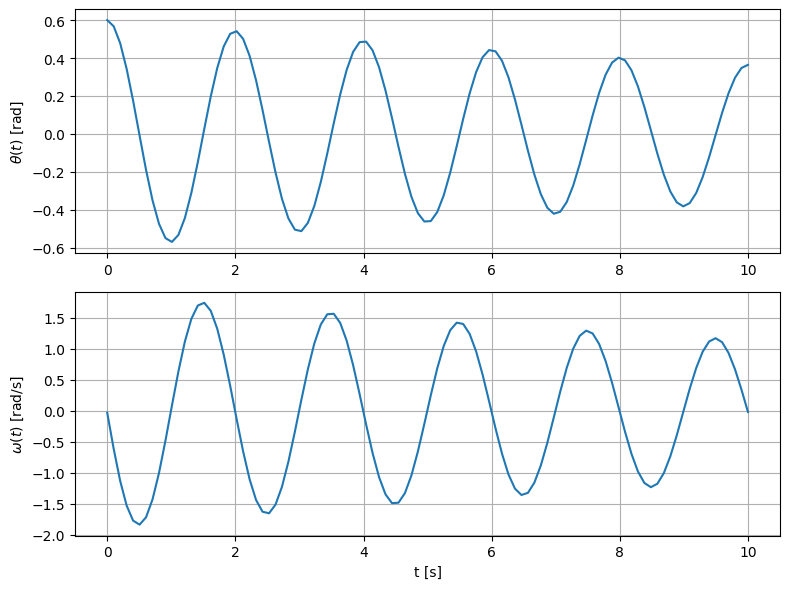

In [ ]:
#Code for damped angle and velocity functions with default parameters
def damped_angle(t, A=0.6, gamma=0.05, omega0=np.pi):
  return A*np.exp(-gamma*t)*np.cos(omega0*t)

#Code for damped velocity function with default parameters
def damped_velocity (t, A=0.6, gamma=0.05, omega0=np.pi):
  return -A*np.exp(-gamma*t)*(gamma*np.cos(omega0*t) + omega0*np.sin(omega0*t))


t = np.linspace(0, 10, 100) # Array of time values from 1 to 10 seconds spaced evenly with 100 points

damped = damped_angle(t) # Since we are using a numpy array,
                        # we can pass the entire array to the function
                        # and it will return an array of angles
velocities = damped_velocity(t) 


fig, ax = plt.subplots(2, 1, figsize=(8, 6))

ax[0].plot(t, damped)
ax[0].set_ylabel(r"$\theta(t)$ [rad]")
ax[0].grid()

ax[1].plot(t, velocities)
ax[1].set_xlabel("t [s]")
ax[1].set_ylabel(r"$\omega(t)$ [rad/s]")
ax[1].grid()

plt.tight_layout()
plt.show()


**Figure 1:** Damped angle $\theta(t)$ and angular velocity $\omega(t)$ for
$A=0.6$, $\gamma=0.05\,\mathrm{s^{-1}}$, and $\omega_0=\pi\,\mathrm{rad/s}$.

## Part 2: Forward and central differences
To approximate derivatives numerically, we use finite-difference formulas.

The forward-difference approximation is

$$
D_f y_i =
\frac{y_{i+1}-y_i}{h}
$$

and the central-difference approximation is

$$
D_c y_i =
\frac{y_{i+1}-y_{i-1}}{2h}.
$$

Here, $y_i$ is the current sampled value, $y_{i+1}$ is the next value, $y_{i-1}$ is the previous value, and $h$ is the spacing between the samples.

The functions `forward_diff()` and `central_diff()` are implemented using NumPy slicing instead of Python loops.

The forward-difference function should return an array of length `len(y)-1`, while the central-difference function should return an array of length `len(y)-2`.

To verify that the implementations work correctly, both functions are tested on:

1. A linear function, where the derivative is constant.
2. A quadratic function, where the analytical derivative is known.


In [60]:
def forward_diff(y, h):
  slice = y[1:] - y[:-1]
  return slice / h


def central_diff(y, h):
  slice = y[2:] - y[:-2]
  return slice / (2 * h)

#### Verification

For the linear test function, the numerical derivative should be constant.

For the quadratic test function, the numerical results can be compared with the known analytical derivative to check the accuracy of the two methods.

##### Linear test:

For the linear test I chose the function: 
$$
y =
3x + 2
$$

Which got a known constant derivative of 3.

In [61]:
x = np.linspace(0, 10, 11)
h = x[1] - x[0]

y = 3 * x + 2

forward = forward_diff(y, h)
central = central_diff(y, h)

print(forward)
print(central)

[3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]
[3. 3. 3. 3. 3. 3. 3. 3. 3.]


Both `forward_diff()` and `central_diff()` return 3, which shows that the functions work as expected for the linear test.

#### Quadratic test:

For the quadric test, I will chose the function
$$
y =
x^2
$$

Which got the derivative
$$
y' =
2x
$$

For the test I chose that x = 2, which gives
$$
y'(2) =
4
$$

I will now use test `forward_diff()` and `central_diff()` with x = 2 and compare them with the analytical derivative.

In [62]:
x = np.linspace(0, 10, 11)
h = x[1] - x[0]

y = x**2

forward = forward_diff(y, h)
central = central_diff(y, h)

print("Forward:")
print("x =", x[:-1])
print("derivative =", forward)

print("\nCentral:")
print("x =", x[1:-1])
print("derivative =", central)

Forward:
x = [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
derivative = [ 1.  3.  5.  7.  9. 11. 13. 15. 17. 19.]

Central:
x = [1. 2. 3. 4. 5. 6. 7. 8. 9.]
derivative = [ 2.  4.  6.  8. 10. 12. 14. 16. 18.]


For $x=2$, the exact derivative is

$$
f'(2)=2\cdot2=4.
$$

Using the forward difference with $h=1$ gives

$$
\frac{3^2 - 2^2}{1} = 5.
$$

Using the central difference gives

$$
\frac{3^2 - 1^2}{2} = 4.
$$

### Conlusion

When we compare the analytical derivative with our code, the numerical derivative, we see that in the linear example both are the same.
However in the quadratic test, the central derivation give us the better result as expected. 



## Part 3: Python function wrapper

In this part I will create a wrapper that can be used with either the `forward_diff` or `central_diff` function. I will then estimate w(0.8) with both functions. Further I will compare both the estimates with the analytical results of the `damped_velocity` function. Last I will demonstarte that the extra arguments in the wrapper works by chosing a non default $A$, $\gamma$ and $\omega_0$.

In the cell below I have created the `derivate_at` function according to the task description.

In [ ]:
def derivative_at(f, x, h, method, *args, **kwargs):
    if method == forward_diff:
        points = np.array([x, x + h]) # We need two points for forward difference, so we take x and x + h

    elif method == central_diff:
        points = np.array([x - h, x, x + h]) # We need three points for central difference, so we take x - h, x, and x + h

    else:
        raise ValueError("Method must be forward_diff or central_diff.") #Simple error handling, making sure we are using correct method.

    y = f(points, *args, **kwargs) # Passing the extra arguments to the damped_angle function.

    return method(y, h)[0]

# Forward differentiation at t = 0.8 seconds
forward_diff_approx = derivative_at(damped_angle, 0.8, 0.01, forward_diff)
print(f"Forward differentiation w(0.8): {forward_diff_approx}")

# Central differentiation at t = 0.8 seconds
central_diff_approx = derivative_at(damped_angle, 0.8, 0.01, central_diff)
print(f"Central differentiation w(0.8): {central_diff_approx}")

# Damped velocity at t = 0.8 seconds
damped_velocity_analytical = damped_velocity(0.8)
print(f"Damped_velocity w(0.8) : {damped_velocity_analytical}\n")

# Calculating the errors
print("Forward differentiation error: ", abs(forward_diff_approx - damped_velocity_analytical))
print("Central differentiation error: ", abs(central_diff_approx - damped_velocity_analytical))



Forward differentiation w(0.8): -1.0174842585012278
Central differentiation w(0.8): -1.041023486202114
Damped_velocity w(0.8) : -1.0411869432307717

Forward differentiation error:  0.023702684729543844
Central differentiation error:  0.00016345702865772083


Comparing the approximations with the analytical answer, we can clearly see that the central differantiation is a better choice for a more accurate result.

I will now prove the `derivative_at` function work with other arguments and repeat the calculations.

In [ ]:
# Forward differentiation at t = 0.8 seconds
forward_diff_approx_non_default = derivative_at(damped_angle, 0.8, 0.01, forward_diff, A=1, gamma=0.1, omega0=2*np.pi)
print(f"Forward differentiation w(0.8): {forward_diff_approx_non_default}")

# Central differentiation at t = 0.8 seconds
central_diff_approx_non_default = derivative_at(damped_angle, 0.8, 0.01, central_diff, A=1, gamma=0.1, omega0=2*np.pi)
print(f"Central differentiation w(0.8): {central_diff_approx_non_default}")

# Damped velocity at t = 0.8 seconds
damped_velocity_analytical_non_default = damped_velocity(0.8, A=1, gamma=0.1, omega0=2*np.pi)
print(f"Damped_velocity w(0.8) : {damped_velocity_analytical}\n")

# Calculating the errors
print("Forward differentiation error: ", abs(forward_diff_approx_non_default - damped_velocity_analytical_non_default))
print("Central differentiation error: ", abs(central_diff_approx_non_default - damped_velocity_analytical_non_default))

Forward differentiation w(0.8): 5.422350133289772
Central differentiation w(0.8): 5.4841377802804425
Damped_velocity w(0.8) : -1.0411869432307717

Forward differentiation error:  0.06535742589374571
Central differentiation error:  0.0035697789030750826


As shown by the code and in the print statements, the wrapper worked with other parameters for $A$, $\gamma$ and $\omega_0$.

## Part 4: Quantifying numerical error

In this part I will quantify the numerical error of $\omega(0.8)$ using the forward and central difference methods.

The analytical value is calculated using `damped_velocity(0.8)`, and the numerical approximations are calculated using `derivative_at()` with different step sizes $h$.

To investigate how the step size affects the accuracy, I use logarithmically spaced values of $h$ from $10^{-16}$ to $10^0$.

For each value of $h$, the absolute error is calculated as

$$
\text{error} =
\left|
\text{numerical approximation}
-
\text{analytical value}
\right|.
$$

The errors for both methods are then plotted in the same log-log figure.

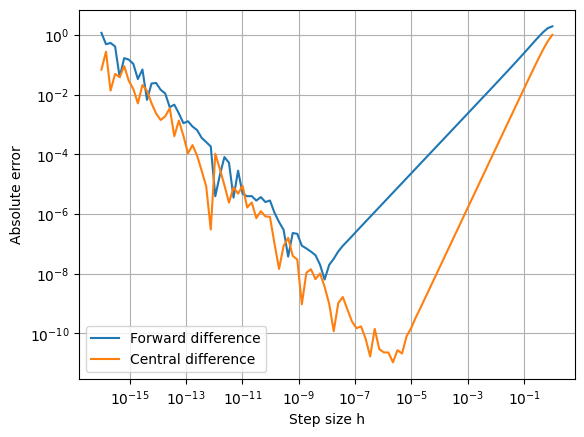

In [ ]:
h_values = np.logspace(-16, 0, 100) # Using logspace to create logarithmically spaced step

# Storing the errors
forward_errors = np.array([]) 
central_errors = np.array([])

# Getting the analytical value
analytical = damped_velocity(0.8)

for h in h_values:

  forward_diff_approx = derivative_at(damped_angle, 0.8, h, forward_diff)
  forward_errors = np.append(forward_errors, abs(forward_diff_approx - analytical))

  central_diff_approx = derivative_at(damped_angle, 0.8, h, central_diff)
  central_errors = np.append(central_errors, abs(central_diff_approx - analytical))

# Using loglog to plot the errors on a logarithmic scale for both axes
plt.loglog(h_values, forward_errors, label="Forward difference")
plt.loglog(h_values, central_errors, label="Central difference")

plt.xlabel("Step size h")
plt.ylabel("Absolute error")
plt.legend()
plt.grid()
plt.show()


In [59]:
best_forward_index = np.argmin(forward_errors)
best_central_index = np.argmin(central_errors)

print("Best forward h:", h_values[best_forward_index])
print("Minimum forward error:", forward_errors[best_forward_index])

print("Best central h:", h_values[best_central_index])
print("Minimum central error:", central_errors[best_central_index])

Best forward h: 8.302175681319769e-09
Minimum forward error: 6.3908038860915894e-09
Best central h: 2.2051307399030503e-06
Minimum central error: 1.0740297540223764e-11


Using `argmin` I get the minimum value of each error array. 

For forward approximation the best step h is: 8.302175681319769e-09 with error of 6.3908038860915894e-09.

For central approximation the best step h is: 2.2051307399030503e-06 with error of 1.0740297540223764e-11.

### Conclusion

The trunucation-error region where h is large happens because the finite-difference formulara are approximated using a large interval,
which gives bigger errors. 

The round-of-error in where the h is small, happens because the differnce between the points calculated are extremly small. Computers store numbers with limited precision, so subcration introuces round of error and increases as h is decresing.

The central diffrence uses points on both sides, while forward difference uses only point on one side. This makes the central difference more accurate. 